In [1]:
%load_ext autoreload
%autoreload 2

# Cella 1: Import dei moduli locali e caricamento della Fase 1
from pathlib import Path
import sys
import numpy as np
import pandas as pd

import copy
import torch
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Individuazione root del progetto per permettere gli import di 'src'
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src import config as cfg
from src import utils as ut
from src import data_loader as dl
from src import train as tr
from src import models as mdl

# Setup Riproducibilità e Device
ut.setup_reproducibility(cfg.FIXED_SEED)
device = ut.get_device()
print(f"Addestramento rete neurale attraverso: {device}")

# Caricamento e validazione dataset
dataset = dl.load_and_validate_dataset(str(cfg.DATASET_PATH))

# Analisi features
dl.inspect_node_features(dataset)

# Analisi dello sbilanciamento delle classi
distribution = dl.check_class_imbalance(dataset)

# Separazione del Test Set finale (Holdout sicuro)
train_val_dataset, test_dataset = dl.stratified_holdout_split(dataset, cfg.TEST_SIZE, cfg.FIXED_SEED)

[INFO] Configurazione di riproducibilità completata con Seed: 42
Addestramento rete neurale attraverso: cpu
[INFO] Dataset caricato con successo. Numero totale di grafi: 1001

===== FEATURE INSPECTION =====
Feature 00 | min=-3.0000 | max=7864.0000 | unique=2169
Feature 01 | min=2.0000 | max=7878.0000 | unique=2153
Feature 02 | min=-538.0000 | max=798.0000 | unique=57
Feature 03 | min=0.0000 | max=120.2704 | unique=32568
Feature 04 | min=-1.0000 | max=1.0000 | unique=3
Feature 05 | min=0.0000 | max=215.6000 | unique=1222
Feature 06 | min=-13.0500 | max=14.4200 | unique=871
Feature 07 | min=0.0000 | max=347.7500 | unique=1658
Feature 08 | min=0.0000 | max=193.9700 | unique=1124
Feature 09 | min=0.0000 | max=211.0000 | unique=28
Feature 10 | min=0.0000 | max=181.0000 | unique=30
Feature 11 | min=0.0000 | max=132.0000 | unique=24
Feature 12 | min=0.0000 | max=169.0000 | unique=30
Feature 13 | min=0.0000 | max=189.0000 | unique=26
Feature 14 | min=0.0000 | max=166.0000 | unique=26
Feature 1

In [2]:
# Griglia di iperparametri (4 combinazioni totali per non appesantire la CPU)
grid_lr = [1e-3, 1e-4]
grid_dropout = [0.1, 0.3]

# Lista di indici delle feature da non normalizzare
excluded_indexes = [4, 29, 30, 31]

results_archive = {}

# ==========================================
# 1. ESPERIMENTI CON ARCHITETTURA GCN
# ==========================================
print("=========================================")
print("AVVIO VALUTAZIONE: PROTEIN GCN")
print("=========================================")

for lr in grid_lr:
    for drop in grid_dropout:
        config_name = f"GCN_lr_{lr}_drop_{drop}"
        print(f"\n>> Testando configurazione: {config_name}")
        
        f1_res, auc_res = tr.run_cross_validation(
            dataset=train_val_dataset,
            model_class=mdl.ProteinGCN,
            n_splits=cfg.N_SPLITS,
            train_fold_fn=tr.train_single_fold,
            lr=lr,
            dropout_p=drop,
            excluded_features=excluded_indexes
        )
        
        results_archive[config_name] = {
            "f1_mean": np.mean(f1_res), "f1_std": np.std(f1_res),
            "auc_mean": np.mean(auc_res), "auc_std": np.std(auc_res)
        }

# ==========================================
# 2. ESPERIMENTI CON ARCHITETTURA GAT
# ==========================================
print("\n=========================================")
print("AVVIO VALUTAZIONE: PROTEIN GAT")
print("=========================================")

for lr in grid_lr:
    for drop in grid_dropout:
        config_name = f"GAT_lr_{lr}_drop_{drop}"
        print(f"\n>> Testando configurazione: {config_name}")
        
        f1_res, auc_res = tr.run_cross_validation(
            dataset=train_val_dataset,
            model_class=mdl.ProteinGAT,
            n_splits=cfg.N_SPLITS,
            train_fold_fn=tr.train_single_fold,
            lr=lr,
            dropout_p=drop,
            excluded_features=excluded_indexes
        )
        
        results_archive[config_name] = {
            "f1_mean": np.mean(f1_res), "f1_std": np.std(f1_res),
            "auc_mean": np.mean(auc_res), "auc_std": np.std(auc_res)
        }

AVVIO VALUTAZIONE: PROTEIN GCN

>> Testando configurazione: GCN_lr_0.001_drop_0.1

   --- FOLD 1/3 ---
   [Epoca 01/50] Training Loss: 0.6764
   [Epoca 10/50] Training Loss: 0.4590
   [Epoca 20/50] Training Loss: 0.3859
   [Epoca 30/50] Training Loss: 0.3336
   [Epoca 40/50] Training Loss: 0.2523
   [Epoca 50/50] Training Loss: 0.1598
   Risultati Fold 1 | Macro F1: 0.7158 | ROC-AUC: 0.7772

   --- FOLD 2/3 ---
   [Epoca 01/50] Training Loss: 0.6755
   [Epoca 10/50] Training Loss: 0.4756
   [Epoca 20/50] Training Loss: 0.4035
   [Epoca 30/50] Training Loss: 0.3140
   [Epoca 40/50] Training Loss: 0.2475
   [Epoca 50/50] Training Loss: 0.1922
   Risultati Fold 2 | Macro F1: 0.7443 | ROC-AUC: 0.7959

   --- FOLD 3/3 ---
   [Epoca 01/50] Training Loss: 0.6816
   [Epoca 10/50] Training Loss: 0.4635
   [Epoca 20/50] Training Loss: 0.3950
   [Epoca 30/50] Training Loss: 0.3211
   [Epoca 40/50] Training Loss: 0.2450
   [Epoca 50/50] Training Loss: 0.1977
   Risultati Fold 3 | Macro F1: 0.7295 

In [3]:
# Conversione dei risultati in un DataFrame leggibile
df_results = pd.DataFrame.from_dict(results_archive, orient="index")
df_results = df_results.sort_values(by="f1_mean", ascending=False)

# Stampa della tabella
print("\n TABELLA COMPARATIVA DELLE CONFIGURAZIONI (CROSS-VALIDATION) ")
df_display = (
    df_results
    .reset_index()
    .rename(columns={'index': 'Configurazione'})
    .round(4)
)
display(df_display.style.hide(axis="index"))

# Estrazione automatica del modello vincente
best_config = df_results.index[0]
best_f1 = df_results.iloc[0]['f1_mean']
best_auc = df_results.iloc[0]['auc_mean']

print("\n=======================================================================")
print(f" MODELLO VINCITORE SELEZIONATO: {best_config}")
print(f" - Macro F1 Medio in CV: {best_f1:.4f}")
print(f" - ROC-AUC Medio in CV: {best_auc:.4f}")
print("=======================================================================\n")


 TABELLA COMPARATIVA DELLE CONFIGURAZIONI (CROSS-VALIDATION) 


Configurazione,f1_mean,f1_std,auc_mean,auc_std
GAT_lr_0.0001_drop_0.3,0.729900,0.022200,0.800800,0.017300
GCN_lr_0.001_drop_0.1,0.729900,0.011600,0.789800,0.008900
GAT_lr_0.001_drop_0.1,0.724600,0.022900,0.795700,0.015000
GAT_lr_0.001_drop_0.3,0.723300,0.012700,0.807700,0.026800
GCN_lr_0.001_drop_0.3,0.722800,0.018400,0.789300,0.020700
GCN_lr_0.0001_drop_0.3,0.715700,0.017800,0.789400,0.016100
GAT_lr_0.0001_drop_0.1,0.711400,0.026500,0.796000,0.029200
GCN_lr_0.0001_drop_0.1,0.704300,0.023400,0.795500,0.013400



 MODELLO VINCITORE SELEZIONATO: GAT_lr_0.0001_drop_0.3
 - Macro F1 Medio in CV: 0.7299
 - ROC-AUC Medio in CV: 0.8008



In [4]:
# ADDESTRAMENTO DEFINITIVO
# Vengono utilizzati esplicitamente i parametri della configurazione vincente emersa dalla CV
best_lr = 1e-4
best_drop = 0.3

# Lancio dell'addestramento finale
final_model, history_loss, final_mean, final_std = tr.train_final_model(
    dataset=train_val_dataset,
    model_class=mdl.ProteinGAT,     # modello vincente
    lr=best_lr,
    dropout_p=best_drop,
    epochs=cfg.DEFAULT_EPOCHS,
    batch_size=cfg.DEFAULT_BATCH_SIZE,
    excluded_features=excluded_indexes
)

[INFO] Avvio Addestramento Finale del modello ProteinGAT...
       Configurazione: LR=0.0001 | Dropout=0.3 | Epoche=50

   [Epoca 01/50] Loss: 0.6876
   [Epoca 10/50] Loss: 0.6155
   [Epoca 20/50] Loss: 0.5650
   [Epoca 30/50] Loss: 0.5341
   [Epoca 40/50] Loss: 0.5150
   [Epoca 50/50] Loss: 0.4977

[INFO] Addestramento finale completato con successo.


 METRICHE DEFINITIVE SUL TEST SET DI HOLDOUT (MODELLO VINCENTE) 
 - Accuracy  : 0.7616
 - Macro F1  : 0.7549  <-- Metrica di riferimento
 - Precision : 0.7031 (Capacità di evitare falsi positivi)
 - Recall    : 0.7258 (Capacità di scovare tutti gli enzimi)
 - ROC-AUC   : 0.7996



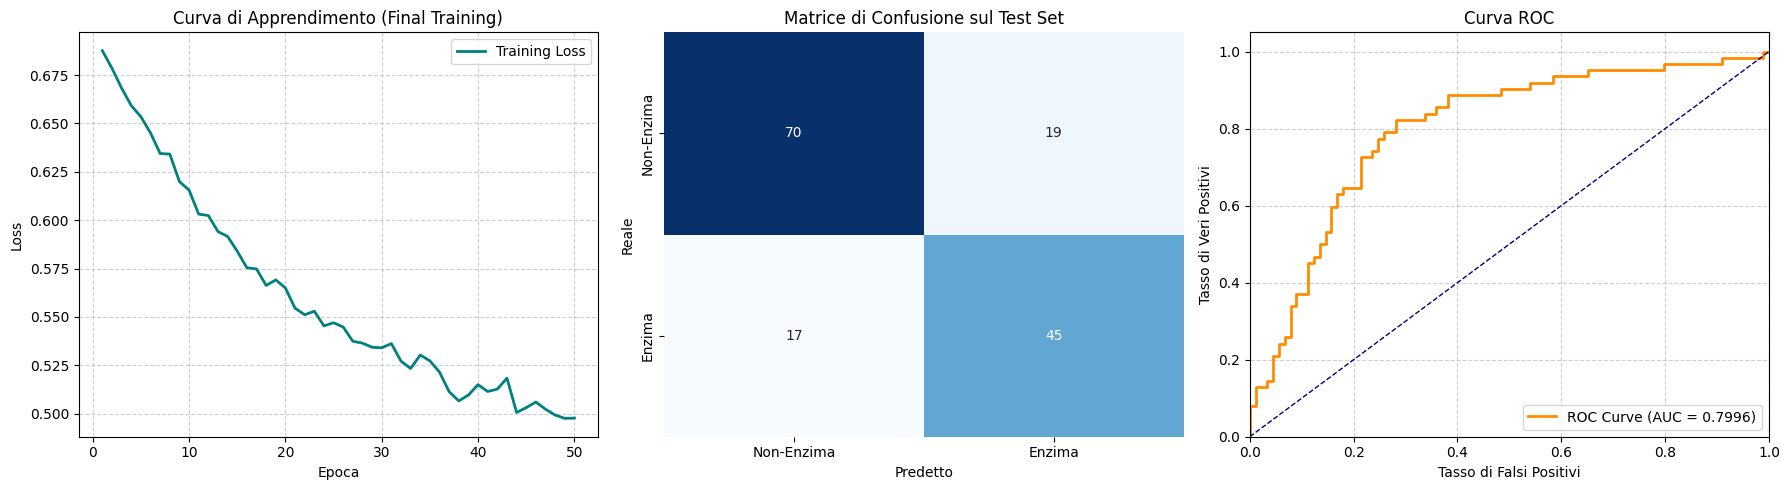

In [5]:
# =======================================================================
# FASE 3: VALUTAZIONE SUL TEST SET DI HOLDOUT
# =======================================================================
# 1. Prepariamo il test set usando la funzione centralizzata (Zero Data Leakage)
test_dataset_normalized = dl.apply_z_score(test_dataset, final_mean, final_std, excluded_features=excluded_indexes)
test_loader = DataLoader(test_dataset_normalized, batch_size=cfg.DEFAULT_BATCH_SIZE, shuffle=False, drop_last=False)

# 2. Invocchiamo la nuova funzione di valutazione centralizzata
y_test_true, y_test_pred, y_test_score = tr.evaluate_model(final_model, test_loader)

# 3. Calcolo delle Metriche Definitive
acc = accuracy_score(y_test_true, y_test_pred)
f1_macro = f1_score(y_test_true, y_test_pred, average="macro")
precision = precision_score(y_test_true, y_test_pred, zero_division=0)
recall = recall_score(y_test_true, y_test_pred)
auc_roc = roc_auc_score(y_test_true, y_test_score)

print("=======================================================================")
print(" METRICHE DEFINITIVE SUL TEST SET DI HOLDOUT (MODELLO VINCENTE) ")
print("=======================================================================")
print(f" - Accuracy  : {acc:.4f}")
print(f" - Macro F1  : {f1_macro:.4f}  <-- Metrica di riferimento")
print(f" - Precision : {precision:.4f} (Capacità di evitare falsi positivi)")
print(f" - Recall    : {recall:.4f} (Capacità di scovare tutti gli enzimi)")
print(f" - ROC-AUC   : {auc_roc:.4f}")
print("=======================================================================\n")

# 4. PLOT DEI GRAFICI (Rimane nel notebook per visualizzazione immediata)
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Grafico A: Curva di Loss
ax[0].plot(range(1, len(history_loss) + 1), history_loss, label='Training Loss', color='teal', linewidth=2)
ax[0].set_title('Curva di Apprendimento (Final Training)')
ax[0].set_xlabel('Epoca')
ax[0].set_ylabel('Loss')
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[0].legend()

# Grafico B: Matrice di Confusione
cm = confusion_matrix(y_test_true, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[1], cbar=False,
            xticklabels=['Non-Enzima', 'Enzima'], yticklabels=['Non-Enzima', 'Enzima'])
ax[1].set_title('Matrice di Confusione sul Test Set')
ax[1].set_xlabel('Predetto')
ax[1].set_ylabel('Reale')

# Grafico C: Curva ROC
fpr, tpr, _ = roc_curve(y_test_true, y_test_score)
ax[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_roc:.4f})')
ax[2].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
ax[2].set_xlim([0.0, 1.0])
ax[2].set_ylim([0.0, 1.05])
ax[2].set_title('Curva ROC')
ax[2].set_xlabel('Tasso di Falsi Positivi')
ax[2].set_ylabel('Tasso di Veri Positivi')
ax[2].grid(True, linestyle='--', alpha=0.6)
ax[2].legend(loc="lower right")

plt.tight_layout()
plt.show()